# Chapter 6: Hierarchical Bayesian Modeling for Edge Cases

Production agent benchmarks are often sliced into fine-grained failure categories with wildly uneven sample sizes ($N_j$ ranging from $3$ to $150$ tasks). When a rare category like `distributed_race_condition` ($N=3, S=0$) shows a $0.0\%$ raw pass rate, developers frequently panic and trigger false regression alerts.

---

## 1. Three Estimators: No Pooling, Complete Pooling, and Partial Pooling

1. **No Pooling (Raw MLE)**:
   $$\hat{\theta}_j^{\text{raw}} = \frac{S_j}{N_j}$$
   Unbiased, but has extreme variance $\frac{\theta_j(1-\theta_j)}{N_j}$ when $N_j \in \{3, 4\}$.
2. **Complete Pooling**:
   $$\hat{\theta}^{\text{pool}} = \frac{\sum_{j=1}^J S_j}{\sum_{j=1}^J N_j}$$
   Zero variance across categories, but completely ignores true differences between easy and hard slices.
3. **Partial Pooling (Hierarchical Beta-Binomial Shrinkage)**:
   We place a shared population hyperprior across all $J=8$ categories:
   $$\theta_j \sim \text{Beta}(\alpha_0, \beta_0), \qquad S_j \mid \theta_j \sim \text{Binomial}(N_j, \theta_j)$$
   Letting $\mu_0 = \frac{\alpha_0}{\alpha_0 + \beta_0}$ be the hyperprior mean and $\kappa = \alpha_0 + \beta_0$ be the prior concentration, the posterior mean for category $j$ is a **convex shrinkage combination**:
   $$\mathbb{E}[\theta_j \mid S_j, N_j] = \frac{\alpha_0 + S_j}{\alpha_0 + \beta_0 + N_j} = \underbrace{\left(\frac{\kappa}{\kappa + N_j}\right)}_{B_j \text{ (Shrinkage Weight)}} \mu_0 + \left(1 - B_j\right) \left(\frac{S_j}{N_j}\right)$$

## 🧠 Layman's Guide: The Opening-Day Baseball Batting Average: Borrowing Strength from the League

![Chapter 6: Hierarchical Bayesian Modeling for Edge Cases — Concept Illustration](../../figures/concepts/ch06_concept.jpg)

Imagine it is Opening Day of the baseball season. A rookie steps up to the plate 3 times and strikes out all 3 times ($0 / 3 = 0.000$ batting average).

- **No Pooling (Panic Mode)**: Looking only at those 3 swings, a naive manager screams: *"His true skill is 0%! Cut him from the roster immediately!"*
- **Complete Pooling (Blind Mode)**: Ignoring the 3 strikeouts completely and saying: *"Every player in Major League Baseball bats .260, so he is a .260 hitter."*
- **Partial Pooling / Bayesian Shrinkage (The Smart Scout)**: A seasoned scout says: *"Three swings is tiny evidence. Since the league average is .260, my best estimate of his true skill right now is pulled (shrunk) strongly toward the league average—around .235. Once he has 150 at-bats, we'll trust his personal stats almost completely."*

### Why This Matters for AI Agents
When you slice an agent benchmark into fine-grained failure categories (e.g., `sql_generation` with $N=150$ tasks vs. `distributed_race_condition` with only $N=3$ tasks), a single unlucky failure in a 3-task category drops the raw pass rate by **33%**! Without **Hierarchical Bayesian Shrinkage**, engineering teams waste days chasing phantom "0% pass rate" emergencies in tiny categories that are just small-sample noise.

### 📖 Plain-English Terminology & Jargon Buster

| Term / Symbol | Plain-English Meaning |
| :--- | :--- |
| **No Pooling ($S_j / N_j$)** | Calculating each category's pass rate in total isolation. Highly accurate for huge categories ($N=150$), wildly noisy for tiny categories ($N=3$). |
| **Complete Pooling** | Lumping all tasks together into one global average ($68.2\%$), ignoring real differences between easy and hard categories. |
| **Partial Pooling (Hierarchical Bayes)** | The gold-standard compromise: each category gets a weighted blend between its own raw score and the global average, weighted by how much data ($N_j$) it has. |
| **Shrinkage Factor ($B_j = \frac{\kappa}{\kappa + N_j}$)** | The 'magnetic pull' toward the global average. When sample size $N_j=3$ is tiny, $B_j \approx 83\%$ (strong pull to the global mean). When $N_j=150$ is huge, $B_j \approx 9\%$ (stays anchored to its own data). |
| **Hyperprior ($\mu_0, \kappa$)** | The overarching 'league average' ($\mu_0$) and consistency strength ($\kappa$) learned automatically across all categories. |
| **Credible Interval (95% CI)** | The horizontal error bar showing the 95% likely range of a category's true pass rate. |

### 📚 Resources & Deeper Reading
- **Efron, B., & Morris, C. (1977).** *Stein's Paradox in Statistics.* Scientific American, 236(5), 119–127. — The famous paper using baseball batting averages to explain why shrinkage estimators beat raw averages.
- **Gelman, A., Carlin, J. B., Stern, H. S., Dunson, D. B., Vehtari, A., & Rubin, D. B. (2013).** *Bayesian Data Analysis (3rd ed., Chapter 5: Hierarchical Models).* CRC Press. [http://www.stat.columbia.edu/~gelman/book/](http://www.stat.columbia.edu/~gelman/book/)
- **McElreath, R. (2020).** *Statistical Rethinking: A Bayesian Course with Examples in R and Stan (2nd ed., Chapter 13: Models With Memory).* CRC Press.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from agent_stats.ch06_hierarchical_bayes import (
    fit_hierarchical_beta_binomial,
    get_sparse_category_dataset,
)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 120

df_raw = get_sparse_category_dataset()
df_est, hyper = fit_hierarchical_beta_binomial(df_raw)

print(f"Estimated Population Hyperprior: alpha_0 = {hyper['alpha_0']:.2f}, beta_0 = {hyper['beta_0']:.2f}")
print(f"Hyperprior Mean (mu_0) = {hyper['prior_mean']:.1%} | Prior Concentration (kappa) = {hyper['prior_concentration_kappa']:.1f} pseudo-trials")

df_est[[
    "category", "N", "S", "true_latent_rate",
    "no_pooling_mean", "complete_pooling_mean", "partial_pooling_mean", "shrinkage_factor"
]].round(3)

Estimated Population Hyperprior: alpha_0 = 11.17, beta_0 = 5.67
Hyperprior Mean (mu_0) = 66.3% | Prior Concentration (kappa) = 16.8 pseudo-trials


,category,N,S,true_latent_rate,no_pooling_mean,complete_pooling_mean,partial_pooling_mean,shrinkage_factor
0,distributed_race_condition,3,0,0.58,0.000,0.716,0.563,0.849
1,memory_leak,4,1,0.60,0.250,0.716,0.584,0.808
2,tls_cert_rotation,7,6,0.68,0.857,0.716,0.720,0.706
3,schema_migration,18,11,0.64,0.611,0.716,0.636,0.483
4,sql_query_optimization,45,31,0.69,0.689,0.716,0.682,0.272
5,oauth_token_refresh,65,43,0.66,0.662,0.716,0.662,0.206
6,api_pagination_handling,110,82,0.74,0.745,0.716,0.735,0.133
7,crud_endpoint_scaffolding,150,114,0.76,0.760,0.716,0.750,0.101


## 2. Forest Plot: Raw Empirical Pass Rates vs. Hierarchically Shrunk Estimates (95% Credible Intervals)

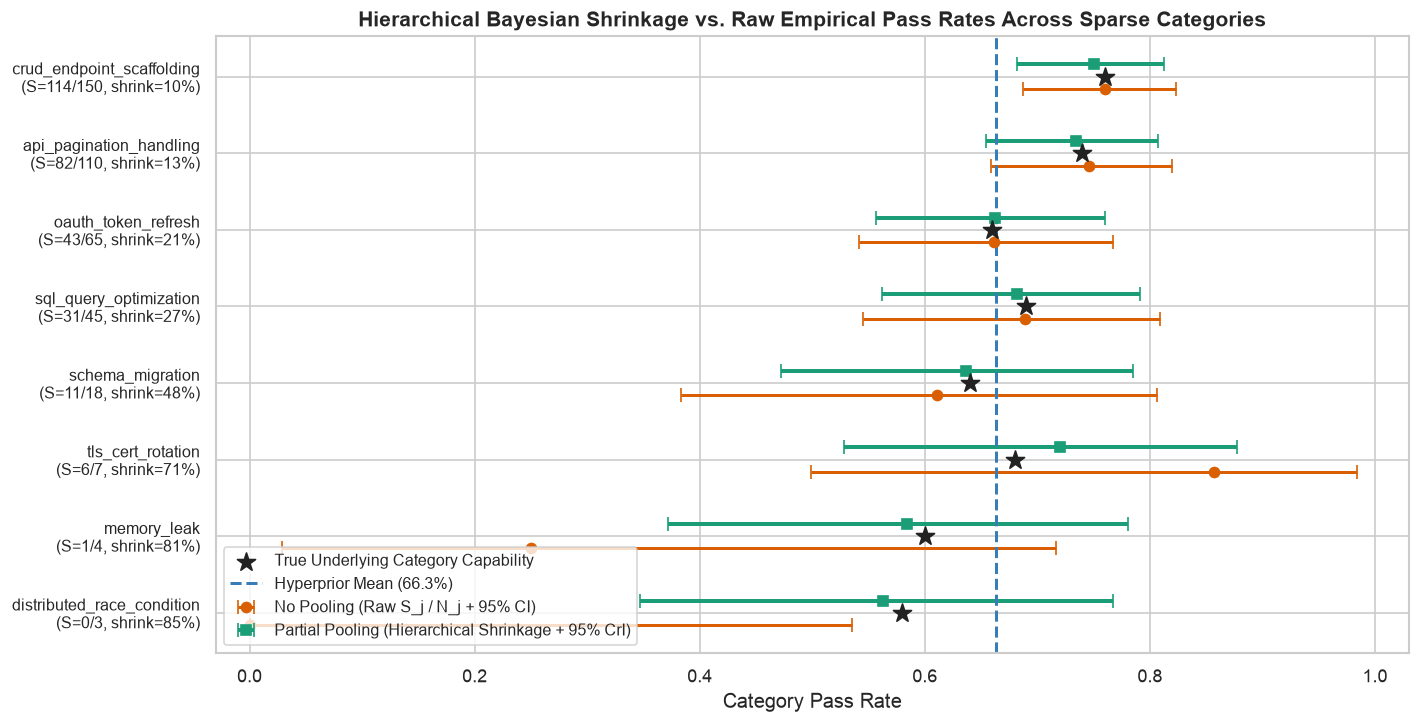

In [2]:
fig, ax = plt.subplots(figsize=(12, 6.2))

y_pos = np.arange(len(df_est))
offset = 0.16

# Plot No-Pooling Raw Estimates + 95% Interval
ax.errorbar(
    df_est["no_pooling_mean"],
    y_pos - offset,
    xerr=[
        df_est["no_pooling_mean"] - df_est["no_pooling_ci_low"],
        df_est["no_pooling_ci_high"] - df_est["no_pooling_mean"],
    ],
    fmt="o",
    color="#d95f02",
    ecolor="#d95f02",
    elinewidth=1.8,
    capsize=4,
    label="No Pooling (Raw S_j / N_j + 95% CI)",
)

# Plot Partial-Pooling Hierarchical Estimates + 95% Credible Interval
ax.errorbar(
    df_est["partial_pooling_mean"],
    y_pos + offset,
    xerr=[
        df_est["partial_pooling_mean"] - df_est["partial_pooling_ci_low"],
        df_est["partial_pooling_ci_high"] - df_est["partial_pooling_mean"],
    ],
    fmt="s",
    color="#1b9e77",
    ecolor="#1b9e77",
    elinewidth=2.4,
    capsize=4,
    label="Partial Pooling (Hierarchical Shrinkage + 95% CrI)",
)

# Plot True Latent Rates for ground-truth reference
ax.scatter(
    df_est["true_latent_rate"],
    y_pos,
    marker="*",
    s=130,
    color="#222222",
    zorder=5,
    label="True Underlying Category Capability",
)

ax.axvline(hyper["prior_mean"], color="#377eb8", linestyle="--", linewidth=1.8, label=f"Hyperprior Mean ({hyper['prior_mean']:.1%})")

labels = [f"{row['category']}\n(S={row['S']}/{row['N']}, shrink={row['shrinkage_factor']:.0%})" for _, row in df_est.iterrows()]
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=9.5)
ax.set_xlabel("Category Pass Rate")
ax.set_xlim(-0.03, 1.03)
ax.set_title("Hierarchical Bayesian Shrinkage vs. Raw Empirical Pass Rates Across Sparse Categories", fontsize=12.5, fontweight="bold")
ax.legend(loc="lower left", fontsize=9.5)

plt.tight_layout()
plt.savefig("figures/ch06_hierarchical_forest_plot.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Case Study Analysis: Preventing False Regression Alarms on $N=3$ Edge Cases

In [3]:
rmse_raw = np.sqrt(np.mean((df_est["no_pooling_mean"] - df_est["true_latent_rate"]) ** 2))
rmse_shrunk = np.sqrt(np.mean((df_est["partial_pooling_mean"] - df_est["true_latent_rate"]) ** 2))

race_row = df_est.loc[df_est["category"] == "distributed_race_condition"].iloc[0]
mem_row = df_est.loc[df_est["category"] == "memory_leak"].iloc[0]

print("=== EDGE-CASE REGRESSION TRIAGE CASE STUDY ===")
print(f"1. `distributed_race_condition` (S=0/3): Raw = {race_row['no_pooling_mean']:.1%} -> Hierarchical = {race_row['partial_pooling_mean']:.1%} "
      f"(95% CrI: [{race_row['partial_pooling_ci_low']:.1%}, {race_row['partial_pooling_ci_high']:.1%}], True = {race_row['true_latent_rate']:.1%})")
print(f"2. `memory_leak` (S=1/4)               : Raw = {mem_row['no_pooling_mean']:.1%} -> Hierarchical = {mem_row['partial_pooling_mean']:.1%} "
      f"(95% CrI: [{mem_row['partial_pooling_ci_low']:.1%}, {mem_row['partial_pooling_ci_high']:.1%}], True = {mem_row['true_latent_rate']:.1%})")
print(f"3. Estimation Error (RMSE vs True Rate): No-Pooling RMSE = {rmse_raw:.3f} vs. Partial-Pooling RMSE = {rmse_shrunk:.3f} "
      f"({(1 - rmse_shrunk/rmse_raw)*100:.1f}% error reduction!)")

=== EDGE-CASE REGRESSION TRIAGE CASE STUDY ===
1. `distributed_race_condition` (S=0/3): Raw = 0.0% -> Hierarchical = 56.3% (95% CrI: [34.7%, 76.7%], True = 58.0%)
2. `memory_leak` (S=1/4)               : Raw = 25.0% -> Hierarchical = 58.4% (95% CrI: [37.2%, 78.1%], True = 60.0%)
3. Estimation Error (RMSE vs True Rate): No-Pooling RMSE = 0.248 vs. Partial-Pooling RMSE = 0.017 (93.1% error reduction!)
